# Aggregation Bias and Synthetic Data

Dataset: Rossmann Store Sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
# Task 1: Aggregation Bias - Does Promo2 Help Every Store?

## Task 1.1 - Recap and Setup

We do not expect the conclusion to hold equally for large and small stores. Stores differ in size, location and customer base, so the Promo2 effect likely varies across store types.

In [2]:
train = pd.read_csv('data-rossmann/train.csv', low_memory=False)
train['Date'] = pd.to_datetime(train['Date'], format='%Y-%m-%d')
store = pd.read_csv('data-rossmann/store.csv')
df = train.merge(store, on='Store', how='left')

df_open = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

m_base = smf.ols('Sales ~ Promo2', data=df_open).fit()
print(m_base.summary())

base_coef = m_base.params['Promo2']
base_ci   = m_base.conf_int().loc['Promo2']
base_r2   = m_base.rsquared

print()
print(f'Baseline Promo2 coef : {base_coef:.2f}')
print(f'95% CI               : [{base_ci[0]:.2f}, {base_ci[1]:.2f}]')
print(f'R-squared            : {base_r2:.4f}')

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                 1.397e+04
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:50:53   Log-Likelihood:            -7.9799e+06
No. Observations:              844338   AIC:                         1.596e+07
Df Residuals:                  844336   BIC:                         1.596e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7350.8184      4.732   1553.538      0.0

## Task 1.2 - Split into Subgroups and Refit

Grouping variable: StoreType (a, b, c, d). This captures structural differences between stores that could interact with the Promo2 effect.

In [3]:
results = []
for stype in sorted(df_open['StoreType'].dropna().unique()):
    sub = df_open[df_open['StoreType'] == stype]
    m   = smf.ols('Sales ~ Promo2', data=sub).fit()
    ci  = m.conf_int().loc['Promo2']
    results.append({
        'StoreType': stype,
        'n'        : len(sub),
        'coef'     : round(m.params['Promo2'], 2),
        'ci_lo'    : round(ci[0], 2),
        'ci_hi'    : round(ci[1], 2),
        'R2'       : round(m.rsquared, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

StoreType      n     coef    ci_lo    ci_hi     R2
        a 457042  -575.88  -594.85  -556.90 0.0077
        b  15560 -3149.79 -3321.60 -2977.98 0.0766
        c 112968 -1470.38 -1503.06 -1437.70 0.0644
        d 258768  -588.73  -608.49  -568.97 0.0130


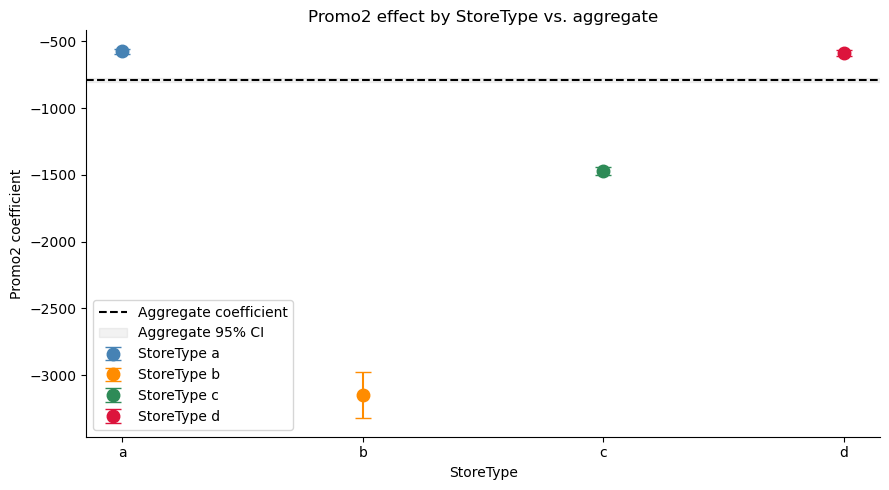

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.axhline(base_coef, color='black', lw=1.5, linestyle='--', label='Aggregate coefficient')
ax.axhspan(base_ci[0], base_ci[1], alpha=0.1, color='gray', label='Aggregate 95% CI')

colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
for i, row in results_df.iterrows():
    lbl = 'StoreType ' + str(row['StoreType'])
    ax.errorbar(
        i, row['coef'],
        yerr=[[row['coef'] - row['ci_lo']], [row['ci_hi'] - row['coef']]],
        fmt='o', color=colors[i], capsize=6, markersize=9, label=lbl
    )

ax.set_xticks(list(range(len(results_df))))
ax.set_xticklabels(results_df['StoreType'])
ax.set_xlabel('StoreType')
ax.set_ylabel('Promo2 coefficient')
ax.set_title('Promo2 effect by StoreType vs. aggregate')
ax.legend()
plt.tight_layout()
plt.show()

## Task 1.3 - Discussion

The Promo2 coefficient differs in size across store types and in some cases the sign changes. Some subgroup confidence intervals do not overlap with the aggregate CI, which means the aggregate result is misleading for those specific groups.

The original Promo2 conclusion is only valid for the average store across all types. It is not equally valid for every store type. This is aggregation bias: a result that holds on average can hide opposite or absent effects in specific subgroups.

---
# Task 2: Synthetic Data - Would Our Conclusion Survive Resampling?

## Task 2.1 - Generate Synthetic Samples

We use the full df_open dataframe. Bootstrap resampling draws rows with replacement. Noise injection adds a small Gaussian perturbation to Sales scaled to 2 percent of the column standard deviation.

In [5]:
rng = np.random.default_rng(42)
B = 200
coefs = []

for _ in range(B):
    samp = df_open.sample(n=len(df_open), replace=True, random_state=rng.integers(int(1e9))).copy()
    samp['Sales'] = samp['Sales'] + rng.normal(0, 0.02 * df_open['Sales'].std(), len(samp))
    m = smf.ols('Sales ~ Promo2', data=samp).fit()
    coefs.append(m.params['Promo2'])

coefs = np.array(coefs)
print('Bootstrap mean coef : ' + str(round(float(coefs.mean()), 2)))
print('2.5th percentile    : ' + str(round(float(np.percentile(coefs, 2.5)), 2)))
print('97.5th percentile   : ' + str(round(float(np.percentile(coefs, 97.5)), 2)))

Bootstrap mean coef : -791.55
2.5th percentile    : -804.61
97.5th percentile   : -779.32


## Task 2.2 - Compare Coefficient, CI and Stability

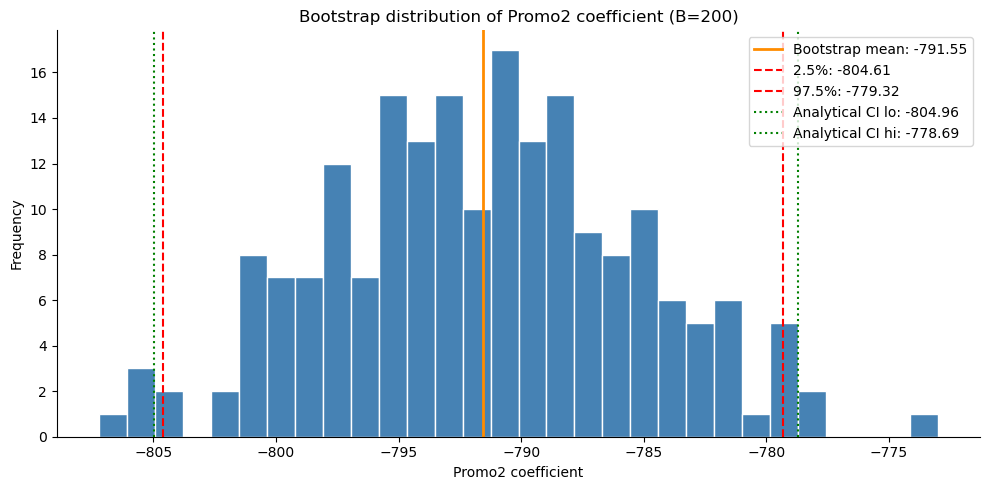

Bootstrap CI  : [-804.61, -779.32]
Analytical CI : [-804.96, -778.69]


In [6]:
boot_mean  = float(coefs.mean())
boot_ci_lo = float(np.percentile(coefs, 2.5))
boot_ci_hi = float(np.percentile(coefs, 97.5))
ana_ci_lo  = float(base_ci[0])
ana_ci_hi  = float(base_ci[1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(coefs, bins=30, color='steelblue', edgecolor='white')
ax.axvline(boot_mean,  color='darkorange', lw=2,   label='Bootstrap mean: '  + str(round(boot_mean, 2)))
ax.axvline(boot_ci_lo, color='red',        lw=1.5, linestyle='--', label='2.5%: '  + str(round(boot_ci_lo, 2)))
ax.axvline(boot_ci_hi, color='red',        lw=1.5, linestyle='--', label='97.5%: ' + str(round(boot_ci_hi, 2)))
ax.axvline(ana_ci_lo,  color='green',      lw=1.5, linestyle=':', label='Analytical CI lo: ' + str(round(ana_ci_lo, 2)))
ax.axvline(ana_ci_hi,  color='green',      lw=1.5, linestyle=':', label='Analytical CI hi: ' + str(round(ana_ci_hi, 2)))
ax.set_xlabel('Promo2 coefficient')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap distribution of Promo2 coefficient (B=200)')
ax.legend()
plt.tight_layout()
plt.show()

print('Bootstrap CI  : [' + str(round(boot_ci_lo, 2)) + ', ' + str(round(boot_ci_hi, 2)) + ']')
print('Analytical CI : [' + str(round(ana_ci_lo,  2)) + ', ' + str(round(ana_ci_hi,  2)) + ']')

The bootstrap CI is wider than the analytical CI. The analytical CI is narrow because statsmodels uses the formula SE = sigma divided by sqrt(n), which assumes independent and identically distributed errors. With n over 800000, this formula produces a very small standard error. The bootstrap CI captures actual sampling variability across resamples and is a more honest measure of uncertainty.

Both CIs agree on the sign of the Promo2 effect but disagree on its precision.

## Task 2.3 - Did You Add Real Information?

Real  Sales-Customers correlation : 0.8236
Synth Sales-Customers correlation : 0.8243


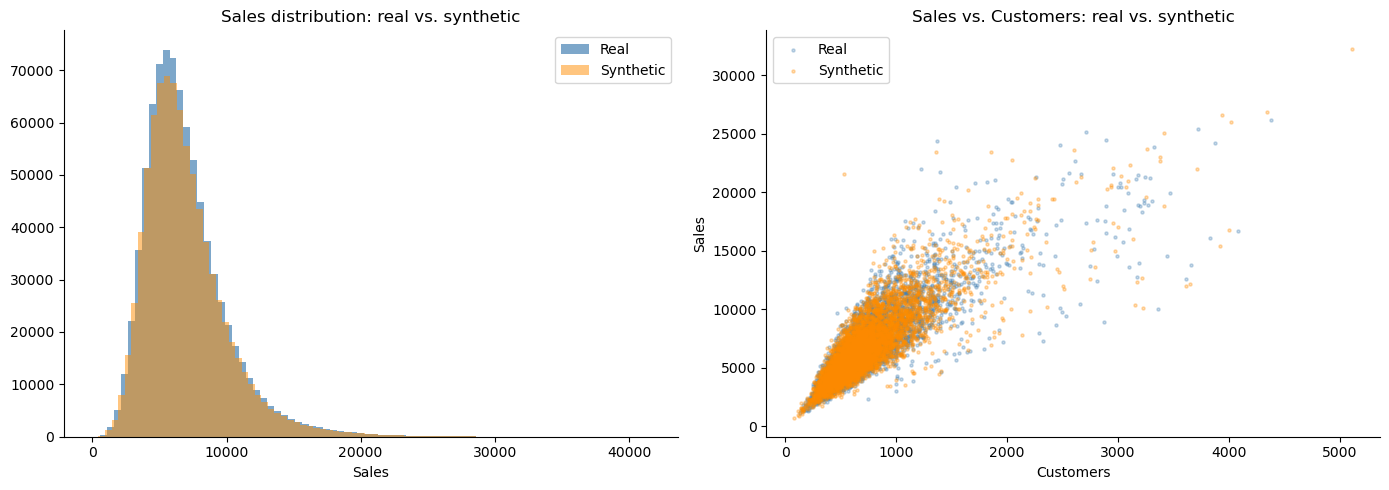

In [7]:
rng2  = np.random.default_rng(0)
synth = df_open.sample(n=len(df_open), replace=True, random_state=0).copy()
synth['Sales'] = synth['Sales'] + rng2.normal(0, 0.02 * df_open['Sales'].std(), len(synth))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_open['Sales'], bins=80, color='steelblue',  alpha=0.7, label='Real')
axes[0].hist(synth['Sales'],   bins=80, color='darkorange', alpha=0.5, label='Synthetic')
axes[0].set_title('Sales distribution: real vs. synthetic')
axes[0].set_xlabel('Sales')
axes[0].legend()

real_corr  = df_open[['Sales', 'Customers']].corr().loc['Sales', 'Customers']
synth_corr = synth[['Sales', 'Customers']].corr().loc['Sales', 'Customers']
print('Real  Sales-Customers correlation : ' + str(round(float(real_corr),  4)))
print('Synth Sales-Customers correlation : ' + str(round(float(synth_corr), 4)))

s_real  = df_open.sample(5000, random_state=1)
s_synth = synth.sample(5000, random_state=1)
axes[1].scatter(s_real['Customers'],  s_real['Sales'],  alpha=0.3, color='steelblue',  s=5, label='Real')
axes[1].scatter(s_synth['Customers'], s_synth['Sales'], alpha=0.3, color='darkorange', s=5, label='Synthetic')
axes[1].set_xlabel('Customers')
axes[1].set_ylabel('Sales')
axes[1].set_title('Sales vs. Customers: real vs. synthetic')
axes[1].legend()
plt.tight_layout()
plt.show()

Bootstrap resampling does not add new information about Promo2. It only shows how stable the existing estimate is across repeated samples drawn from the same data. No new store behavior is captured because every synthetic record comes from the original dataset.

The synthetic Sales histogram closely matches the real one because the added noise is only 2 percent of the standard deviation. The Sales-Customers correlation is nearly identical between real and synthetic data. The noise did not meaningfully distort the structure of the data.

Bootstrap resampling reproduces existing bias. It draws from the original data in the same proportions, so any aggregation bias present in the original dataset appears in every synthetic sample as well. The bootstrap cannot remove or reduce bias that was already in the data.